In [1]:
import os
import urllib.request
from urllib.error import HTTPError
from tokenizers import ByteLevelBPETokenizer
import time
import numpy as np
import multiprocessing as mp
import tensorflow as tf
import matplotlib.pyplot as plt

2026-03-06 00:32:27.878725: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772757148.197117      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772757148.285905      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772757149.002169      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772757149.002235      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772757149.002238      17 computation_placer.cc:177] computation placer alr

# Data exploration

We will look into the distribution of the number of tokens.
As a prerequisite, we need to:
  - download the dataset
  - Build the BPE tokenizer

Let start with downloading the dataset.

In [2]:
!rm data.py configs.py tokenizer.py
!rm -rf de_tokenizer_30_000_vocab_size_model
!rm -rf en_tokenizer_30_000_vocab_size_model

rm: cannot remove 'data.py': No such file or directory
rm: cannot remove 'configs.py': No such file or directory
rm: cannot remove 'tokenizer.py': No such file or directory


In [3]:
base_url = "https://raw.githubusercontent.com/MiguelSteph/transformer-from-scratch/main/"
def download_file_from_github(file_path: str, file_name: str):
    if not os.path.isfile(file_name):
        file_url = base_url + file_path
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_name)
        except HTTPError as e:
            print("Something went wrong. Please try to download the file directly from the GitHub repository:\n", e)

file_paths = [
    'configs/configs.py',
    'data/tokenizer.py',
    'data/data.py'
]
file_names = [
    'configs.py',
    'tokenizer.py',
    'data.py'
]

for file_path, file_name in zip(file_paths, file_names): 
    download_file_from_github(file_path, file_name)

In [4]:
from configs import get_configs
from data import build_and_save_tokenizer_models, download_and_get_raw_datasets

config = get_configs()

# Build and save BPE tokenizer model

This is one time script that will create the BPE tokenizer model and dave it.

In [5]:
build_and_save_tokenizer_models()

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/wmt_translate/de-en/incomplete.YM1QQ4_1.0.0/wmt_translate-test.tfrecord*..…

Dataset wmt_translate downloaded and prepared to /root/tensorflow_datasets/wmt_translate/de-en/1.0.0. Subsequent calls will reuse this data.


2026-03-06 00:42:12.394353: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


--- Starting German tokenizer ---



--- German tokenizer built and saved ---
--- Starting English tokenizer ---



--- English tokenizer built and saved ---


# Data exploration

In [6]:
train_ds, validation_ds, test_ds = download_and_get_raw_datasets()
full_ds = train_ds.concatenate(validation_ds).concatenate(test_ds)
de_data = full_ds.map(lambda x: x["de"], num_parallel_calls=tf.data.AUTOTUNE)
en_data = full_ds.map(lambda x: x["en"], num_parallel_calls=tf.data.AUTOTUNE)

de_tokenizer = ByteLevelBPETokenizer(config.data.de_tokenizer_model_path + '/vocab.json',
                                     config.data.de_tokenizer_model_path + '/merges.txt')
de_tokenizer.add_special_tokens(list(config.data.special_tokens))
en_tokenizer = ByteLevelBPETokenizer(config.data.en_tokenizer_model_path + '/vocab.json',
                                     config.data.en_tokenizer_model_path + '/merges.txt')
en_tokenizer.add_special_tokens(list(config.data.special_tokens))

def get_en_tokens_length(input: np.ndarray) -> list[int]:
    lengths = []
    for sample in input:
        lengths.append(len(en_tokenizer.encode(sample.decode('utf-8')).ids))
    return lengths

def get_de_tokens_length(input: np.ndarray) -> list[int]:
    lengths = []
    for sample in input:
        lengths.append(len(de_tokenizer.encode(sample.decode('utf-8')).ids))
    return lengths

start_time = time.time()
cpu_count = os.cpu_count()
with mp.Pool(cpu_count) as pool:
    de_tokens_lengths = []
    for tokens_length in pool.imap(get_de_tokens_length, de_data.batch(100).as_numpy_iterator(), chunksize=16):
        de_tokens_lengths.extend(tokens_length)

print(f"German Token length counting took {time.time() - start_time}")


start_time = time.time()
cpu_count = os.cpu_count()
with mp.Pool(cpu_count) as pool:
    en_tokens_lengths = []
    for tokens_length in pool.imap(get_en_tokens_length, en_data.batch(100).as_numpy_iterator(), chunksize=16):
        en_tokens_lengths.extend(tokens_length)

print(f"English Token length counting took {time.time() - start_time}")

German Token length counting took 369.5346529483795
English Token length counting took 341.22591257095337


Max token length for german sentences is 10104
Max token length for english sentences is 14786

Min token length for german sentences is 1
Min token length for english sentences is 1


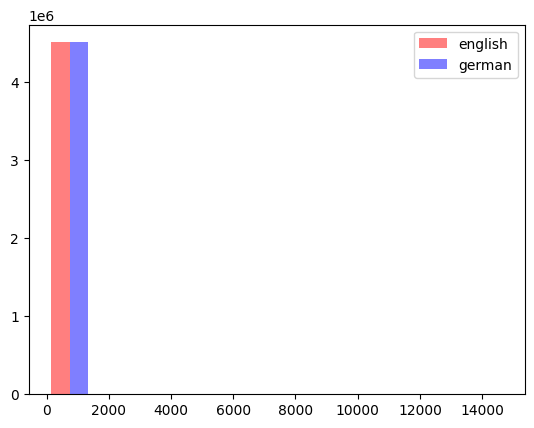

In [7]:
print(f"Max token length for german sentences is {max(de_tokens_lengths)}")
print(f"Max token length for english sentences is {max(en_tokens_lengths)}")
print()
print(f"Min token length for german sentences is {min(de_tokens_lengths)}")
print(f"Min token length for english sentences is {min(en_tokens_lengths)}")

plt.hist([en_tokens_lengths, de_tokens_lengths], color=['r', 'b'], label=['english', 'german'], alpha=0.5)
plt.legend()
plt.show()

With max_seq_len set to 100, we have 27917 german samples sentences out of range.
With max_seq_len set to 100, we have 22934 german samples sentences out of range.


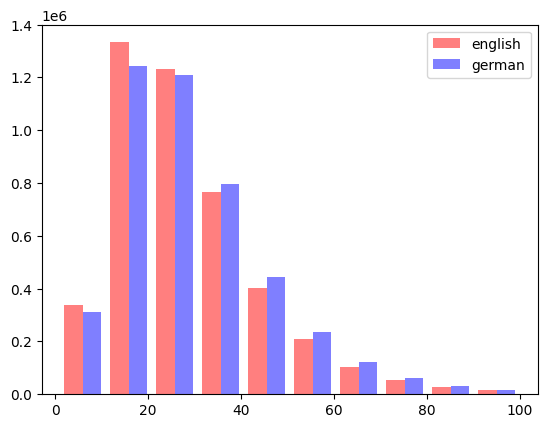

In [8]:
max_tokens = 100
de_out_of_range_samples = sum(item > max_tokens for item in de_tokens_lengths)
en_out_of_range_samples = sum(item > max_tokens for item in en_tokens_lengths)
print(f"With max_seq_len set to {max_tokens}, we have {de_out_of_range_samples} german samples sentences out of range.")
print(f"With max_seq_len set to {max_tokens}, we have {en_out_of_range_samples} german samples sentences out of range.")

de_reduced_tokens_lengths = [token_len for token_len in de_tokens_lengths if token_len <= max_tokens]
en_reduced_tokens_lengths = [token_len for token_len in en_tokens_lengths if token_len <= max_tokens]

plt.hist([en_reduced_tokens_lengths, de_reduced_tokens_lengths], color=['r', 'b'], label=['english', 'german'], alpha=0.5)
plt.legend()
plt.show()


In [9]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session